In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score ,confusion_matrix ,classification_report


In [2]:
df = pd.read_csv("data/smart_beverage_recommender.csv")
df.head()

,temperature_c,humidity_percent,time_of_day_hours,perfect_order
0,16,36,7,Ginger tea
1,29,20,12,Plain chai
2,38,70,17,Elaichi chai
3,24,64,11,Plain chai
4,20,23,9,Plain chai


In [3]:
print(df.isnull().sum())
print(df.info())

temperature_c        0
humidity_percent     0
time_of_day_hours    0
perfect_order        0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   temperature_c      1000 non-null   int64
 1   humidity_percent   1000 non-null   int64
 2   time_of_day_hours  1000 non-null   int64
 3   perfect_order      1000 non-null   str  
dtypes: int64(3), str(1)
memory usage: 31.4 KB
None


In [4]:
X = df[["temperature_c","humidity_percent","time_of_day_hours"]]
y = df["perfect_order"]
print(f"Loaded {len(df)} into the pipeline")

Loaded 1000 into the pipeline


In [ ]:
X_train , X_test ,y_train ,y_test = train_test_split(X,y , test_size=0.2 , random_state=42)

print(f"Training on this Much of data : {len(X_train)} ")
print(f"Testing on this Much of data : {len(X_test)} ")

Training on this Much of data : 800 
Testing on this Much of data : 200 


In [11]:
# Random Forest Model
classifier_rf = RandomForestClassifier(n_estimators=100,random_state=42)
classifier_rf.fit(X_train,y_train)
predicted_rf = classifier_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test , predicted_rf)

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

In [12]:
# Logistic Regression

classifier_lg = Pipeline([
        ('scaler',StandardScaler()),
        ('model' , LogisticRegression(max_iter=1000,random_state=42))
    ])
classifier_lg.fit(X_train,y_train)
predicted_lg = classifier_lg.predict(X_test)
accuracy_lg = accuracy_score(y_test,predicted_lg)


In [13]:
# K-Nearest-Neighbours

classifier_knn = Pipeline([
    ('scaler',StandardScaler()),
    ('model',KNeighborsClassifier(n_neighbors=6))
])
classifier_knn.fit(X_train,y_train)
predicted_knn = classifier_knn.predict(X_test)
accuracy_knn = accuracy_score(y_test,predicted_knn)

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


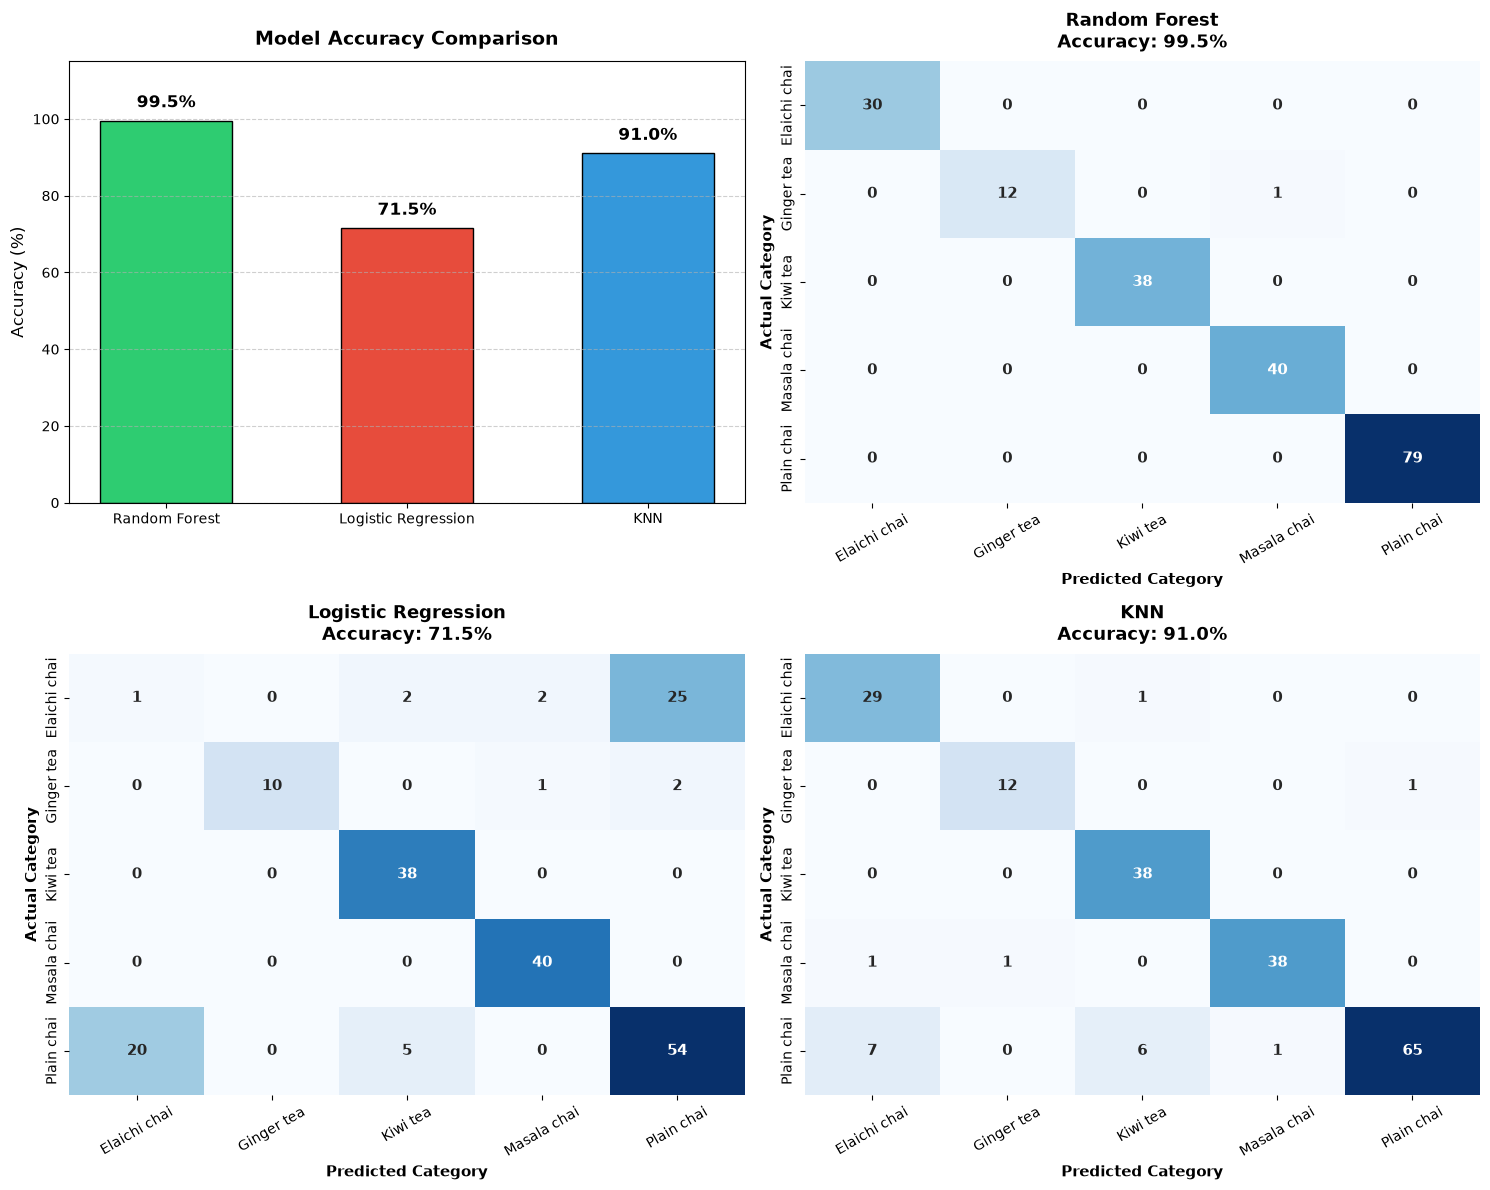

In [17]:
models_data = {
    "Random Forest" : (accuracy_rf , predicted_rf),
    "Logistic Regression" : (accuracy_lg , predicted_lg),
    "KNN" : (accuracy_knn , predicted_knn),
}

labels = sorted(y_test.unique())

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

model_names = list(models_data.keys())
acc_percentages = [models_data[m][0] * 100 for m in model_names]
colors = ['#2ecc71', '#e74c3c', '#3498db']

bars = axes[0].bar(model_names, acc_percentages, color=colors, edgecolor='black', width=0.55)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_ylim(0, 115)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Display exact percentage text on top of each bar
for bar, val in zip(bars, acc_percentages):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        val + 2.5,
        f'{val:.1f}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# --- Plots 2 to 4: Confusion Matrix for Each Model ---
for idx, (m_name, (acc, preds)) in enumerate(models_data.items(), start=1):
    cm = confusion_matrix(y_test, preds, labels=labels)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[idx],
        xticklabels=labels,
        yticklabels=labels,
        cbar=False,
        annot_kws={"size": 11, "weight": "bold"}
    )
    axes[idx].set_title(f'{m_name}\nAccuracy: {acc * 100:.1f}%', fontsize=13, fontweight='bold', pad=10)
    axes[idx].set_xlabel('Predicted Category', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Actual Category', fontsize=11, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [22]:
classification_reports_rf = classification_report(y_test , predicted_rf)
classification_reports_knn = classification_report(y_test , predicted_knn)
classification_reports_lg = classification_report(y_test , predicted_lg)

print("Random Forest Classificer")
print(classification_reports_rf)
print("Logistic Regression")
print(classification_reports_lg)

Random Forest Classificer
              precision    recall  f1-score   support

Elaichi chai       1.00      1.00      1.00        30
  Ginger tea       1.00      0.92      0.96        13
    Kiwi tea       1.00      1.00      1.00        38
 Masala chai       0.98      1.00      0.99        40
  Plain chai       1.00      1.00      1.00        79

    accuracy                           0.99       200
   macro avg       1.00      0.98      0.99       200
weighted avg       1.00      0.99      0.99       200

Logistic Regression
              precision    recall  f1-score   support

Elaichi chai       0.05      0.03      0.04        30
  Ginger tea       1.00      0.77      0.87        13
    Kiwi tea       0.84      1.00      0.92        38
 Masala chai       0.93      1.00      0.96        40
  Plain chai       0.67      0.68      0.68        79

    accuracy                           0.71       200
   macro avg       0.70      0.70      0.69       200
weighted avg       0.68      0.

In [23]:
# Now Best Model is the Random Forest classifier

In [24]:
import joblib

joblib.dump(classifier_rf,"chai_model.joblib")

['chai_model.joblib']